# Variational Autoencoder for the MINIST Dataset

In [109]:
# Deep learning and neural networks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Loading and transforming the MINIST dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image

#from vae import VAE
# // TODO: Arreglar

# General-purpose libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
class Gaussian_VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=512, latent_dim=10):
        super(Gaussian_VAE, self).__init__()

        # -----------
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        
        # --- ENCODER ---
        """
        The encoder maps the input data to a latent space.
        Given an input x, it outputs the parameters of the latent distribution (q_theta(z|x)).
            Since we use a Gaussian VAE, it outputs the mean (mu) and variance (var) of the Gaussian distribution.
            Since the variance must be positive, we output log_var (the logarithm of the variance) instead of var directly, and then we can exponentiate it to get the variance.

        It consists of two linear layers:
        1. encoder_hidden: Maps the input to a hidden representation.
        2.1. fc_mu: Maps the hidden representation to the mean of the latent distribution.
        2.2. fc_logvar: Maps the hidden representation to the log variance of the latent distribution.
        """

        self.encoder_hidden = nn.Linear(input_dim, hidden_dim)
        self.encoder_hidden_activation = nn.ReLU()
        
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_mu_activation = nn.Identity()
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim) 
        self.fc_logvar_activation = nn.Identity()

        # --- DECODER ---
        """
        The decoder maps the latent space back to the original data space.
        Given a latent vector z, it outputs the parameters of the reconstructed input distribution (p_theta(x|z)).
            Since we use a Gaussian VAE, it outputs the mean of the mean (mu) of the Gaussian distribution.
            The variance is assumed to be fixed (e.g., 1).
        
        It consists of two linear layers:
        1. decoder_hidden: Maps the latent vector z to a hidden representation.
        2. decoder_output: Maps the hidden representation to the mean of the reconstructed input distribution.
        """
        self.decoder_hidden = nn.Linear(latent_dim, hidden_dim)
        self.decoder_hidden_activation = nn.ReLU()
        self.decoder_output = nn.Linear(hidden_dim, input_dim)
        self.decoder_output_activation = nn.Identity()

        
    def encode(self, x):
        """
        Encode the input data x into the latent space.

        Returns the mean (mu) and log variance (log_var) of the latent distribution.
        """
        hidden = self.encoder_hidden_activation(self.encoder_hidden(x))

        mu      = self.fc_mu_activation     (self.fc_mu(hidden))
        log_var = self.fc_logvar_activation (self.fc_logvar(hidden))
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick to sample from N(mu, var) from N(0,1).

        This allows us to backpropagate through the sampling process.
        """
        if self.training:
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)     # In each dimension of the latent space, we sample from N(0,1) to get a random value. This is the "noise" we add to the mean to get a sample from the distribution.
            return mu + eps * std
        else:
            # In evaluation mode, we just return the mean (mu) as the latent vector to avoid randomness in the output.
            return mu

    def decode(self, z):
        """Reconstruct the input data from the latent vector z.

        Returns the mean of the reconstructed input distribution (p_theta(x|z)).
        """
        hidden = self.decoder_hidden_activation(self.decoder_hidden(z))
        return self.decoder_output_activation(self.decoder_output(hidden)) 
    
    def forward(self, x):
        """
        Forward pass through the VAE.

        Parameters:
        - x: Input batch to process. x.size(0) is the batch size

        Returns:
        - mu_reconstruction: The mean of the reconstructed input distribution (p_theta(x|z)).
        - mu: The mean of the latent distribution (q_theta(z|x)).
        - log_var: The log variance of the latent distribution (q_theta(z|x)).
        """
        
        # Flattens the input automatically to the expected dimension (batch_size, input_dim)
        x_flat = x.view(x.size(0), -1)

        mu_latent, log_var_latent = self.encode(x_flat)      # They are the parameters of the latent distribution (q_theta(z|x))
        z = self.reparameterize(mu_latent, log_var_latent)

        mu_reconstruction = self.decode(z)
        return mu_reconstruction, mu_latent, log_var_latent

In [111]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


### Downloading the dataset

The MINST dataset is a collection of handwritten digits that is commonly used for training various image processing systems. It contains 60,000 training images and 10,000 testing images. Each image is a 28x28 grayscale image.

In this part, we will download the dataset using the `torchvision` library.

In [112]:
trainset =  torchvision.datasets.MNIST(root='./data', train=True,   download=True, transform=transforms.ToTensor())
testset =   torchvision.datasets.MNIST(root='./data', train=False,  download=True, transform=transforms.ToTensor())

### Training and Validation Sets

For the training set, only the first 1000 samples of each class (0-9) are selected to create a balanced validation set with 1000 samples per class. This results in a total of 10000 samples for the validation set.

For the validation set, only the first 1000 samples are selected.

In [113]:
# Training set transformed into numpy arrays for easier manipulation
x_train = trainset.data.numpy()
y_train = trainset.targets.numpy()

# Creating a balanced validation set with 1000 samples per class

idx = []
for j in range(10):
    # It selects the first 1000 indices of the class j from the training set
    # to create a balanced validation set with 1000 samples per class.
    indices_clase = np.where(y_train == j)[0][:1000]
    idx.extend(indices_clase)

x_train_pre  = x_train[idx]
y_train      = y_train[idx]

In [114]:
# Creating the validation set with 1000 samples

x_val_pre    = testset.data[:1000].numpy()
y_val        = testset.targets[:1000].numpy()

### Examples of the dataset

Some examples of the dataset are shown below. Each image is a 28x28 grayscale image representing a handwritten digit.

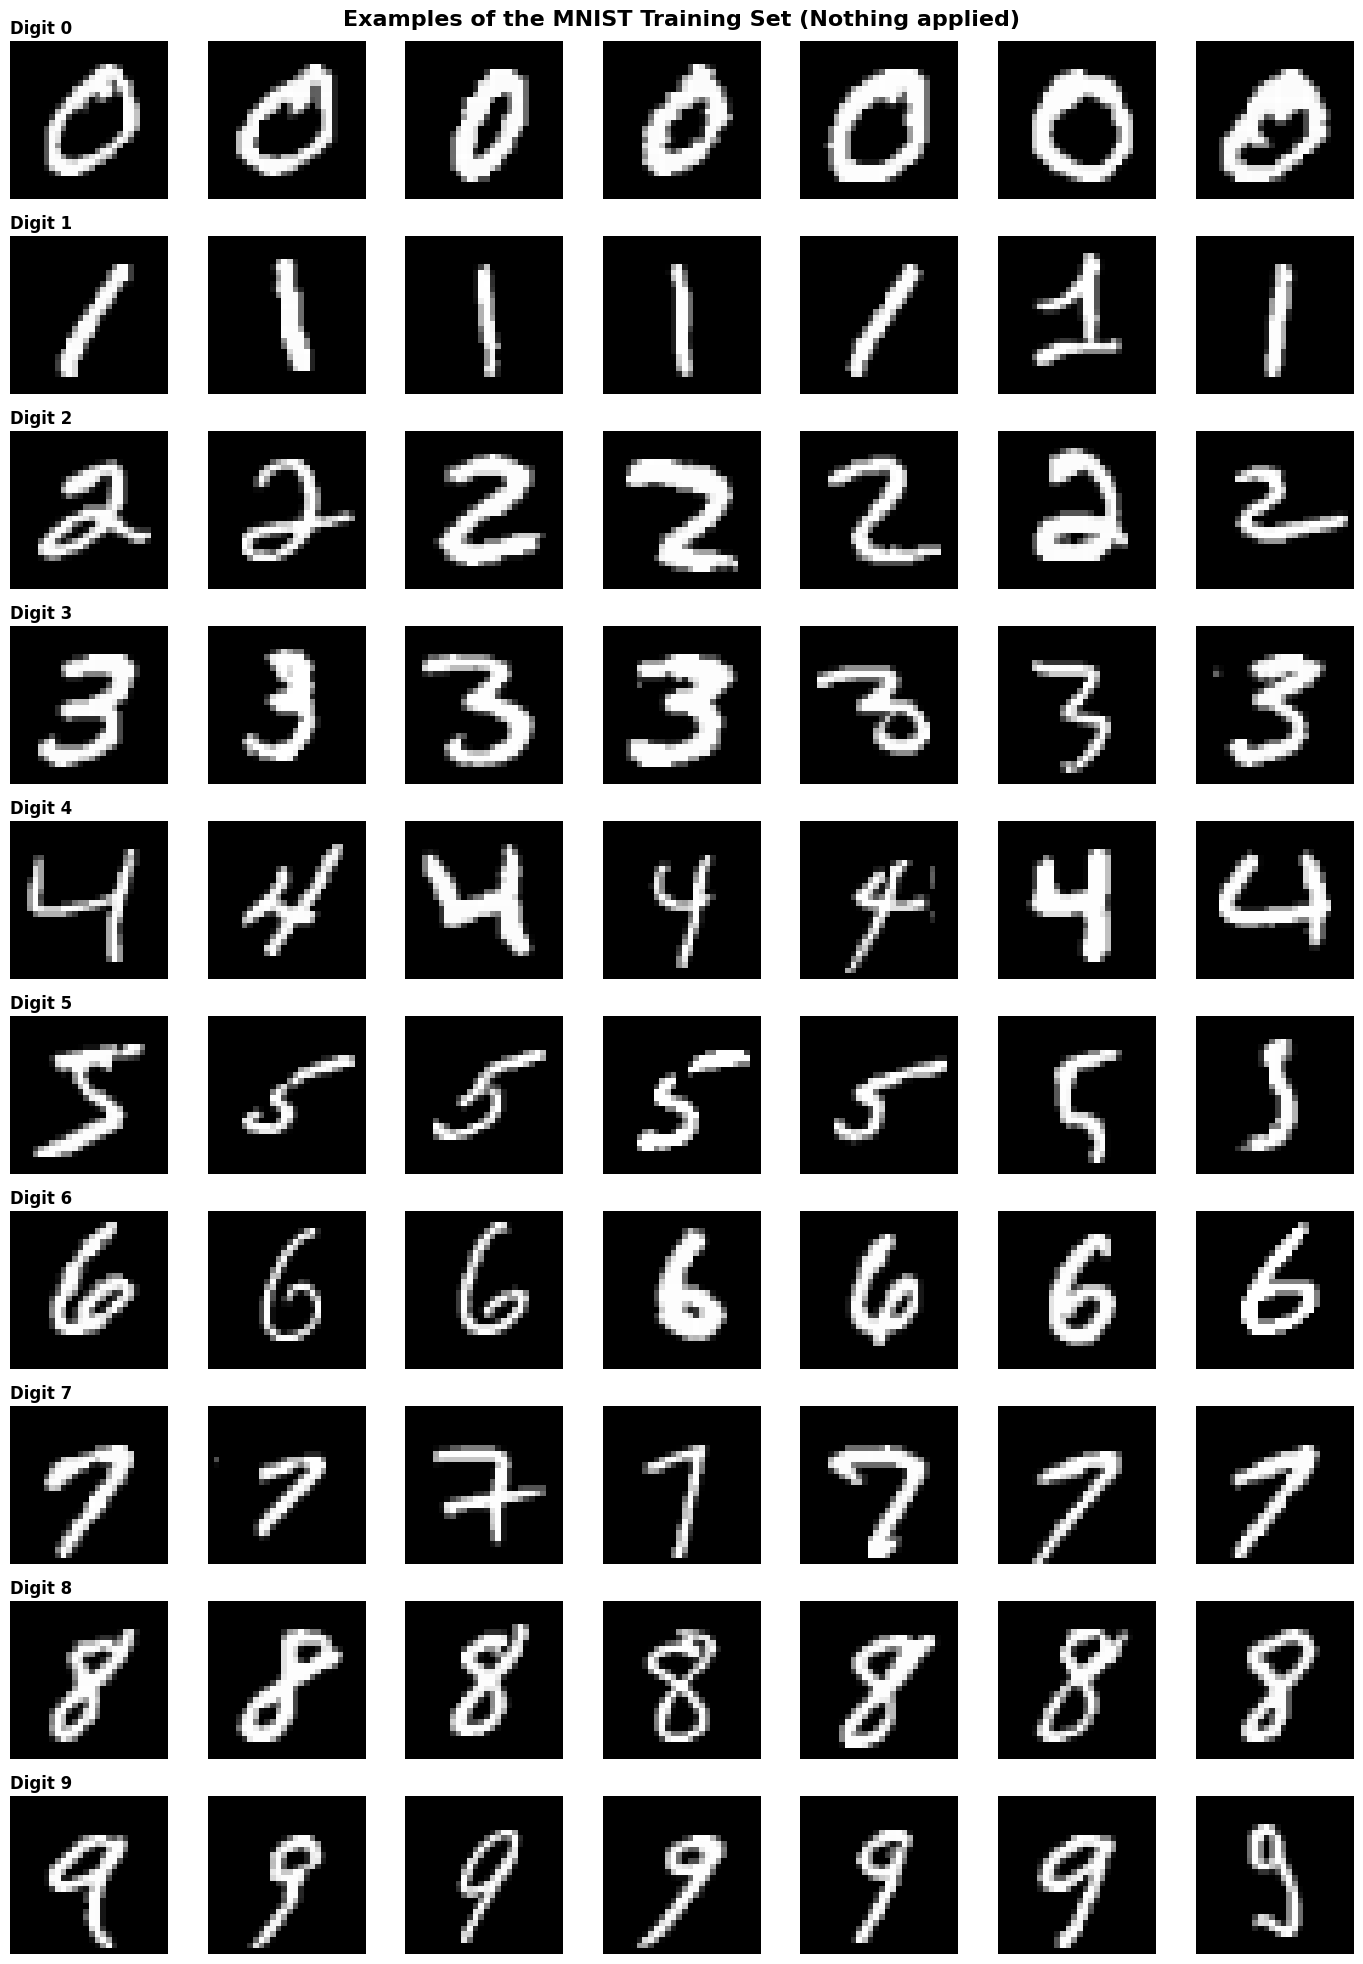

In [115]:
def show_examples(x_data, y_data, num_classes=10, num_photos=5, title=None):
    """
    Displays a grid of images from the dataset.

    Parameters:
    - x_data: The input data (images) to display.
    - y_data: The corresponding labels for the images.
    - num_classes: Number of classes to display (default is 10 for MNIST).
    - num_photos: Number of photos per class to display (default is 5).
    - title: Title for the entire figure (default is None).
    """
    
    fig, axes = plt.subplots(num_classes, num_photos, figsize=(num_photos * 2, num_classes * 2))
    
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for digit in range(num_classes):
        # Get indices of all images belonging to the current digit
        digit_indices = np.where(y_data == digit)[0]
        
        for photo_idx in range(num_photos):
            # Select the current index for the digit
            current_idx = digit_indices[photo_idx]
            
            # Select the appropriate axis for the current digit and photo index
            ax = axes[digit, photo_idx]
            
            ax.imshow(x_data[current_idx], cmap='gray')
            ax.axis('off')  # No need to see the axis for each image
            
            if photo_idx == 0:
                ax.set_title(f'Digit {digit}', loc='left', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


show_examples(x_train_pre, y_train, num_classes=10, num_photos=7, title="Examples of the MNIST Training Set (Nothing applied)")

### Image Redimensioning

Images are redimensioned from 28x28 to 14x14 to reduce the number of parameters in the model.

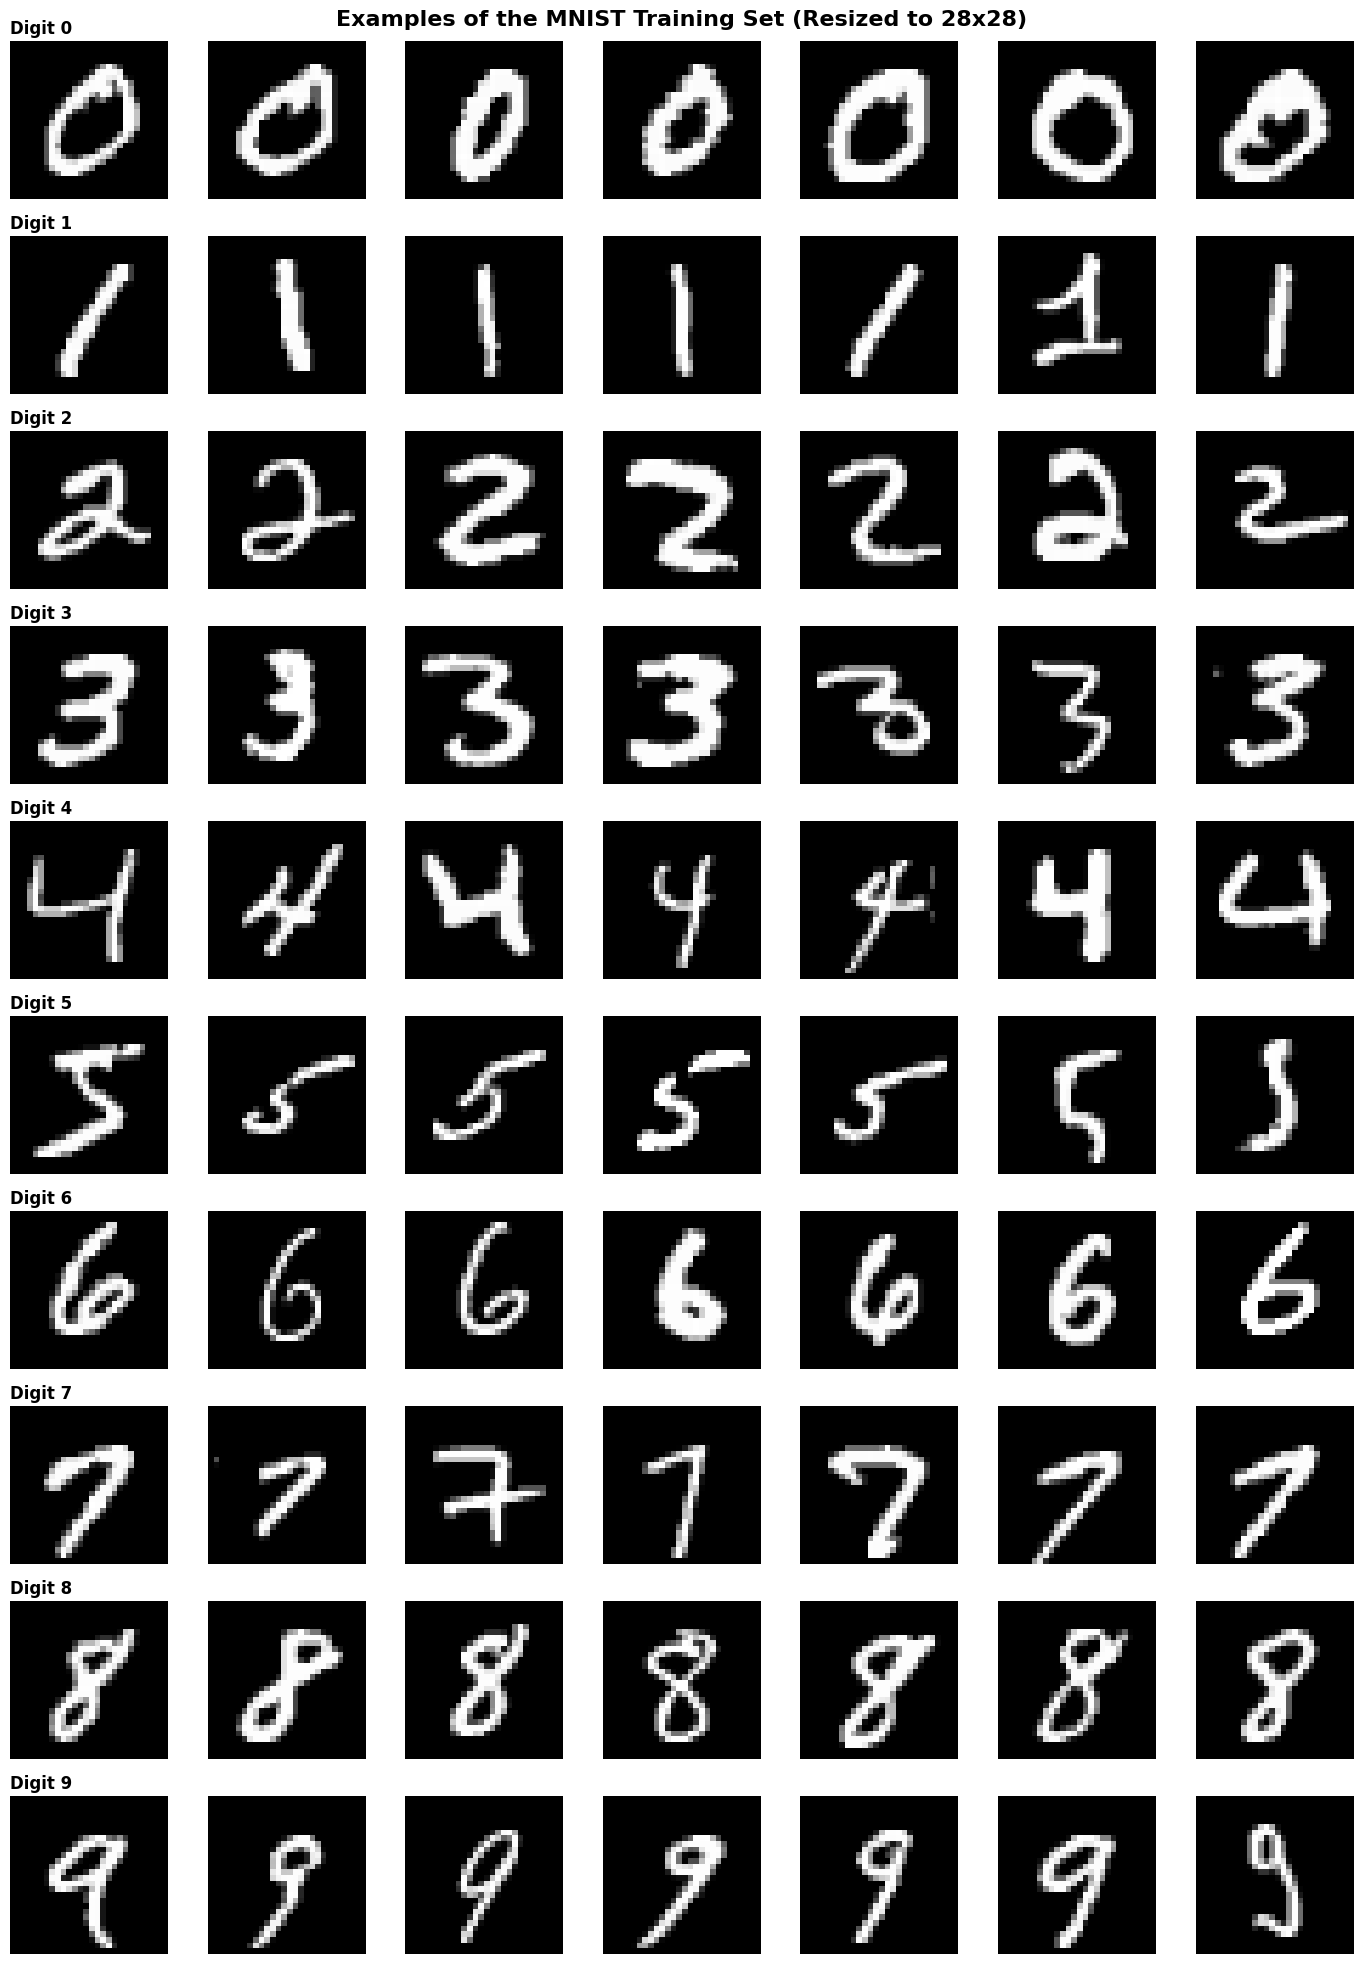

In [116]:
def resize_images(images, new_size=(14, 14)):
    """
    Resize a batch of images to a new size using OpenCV.

    Parameters:
    - images: A numpy array of shape (num_images, height, width) containing the images to be resized.
    - new_size: A tuple (new_height, new_width) specifying the desired size of the output images.

    Returns:
    - A numpy array of shape (num_images, new_height, new_width) containing the resized images.
    """


    num_imgs = images.shape[0]
    new_width, new_height = new_size


    resized = np.zeros((num_imgs, new_height, new_width), dtype=np.float32)
    for i in range(num_imgs):
        resized[i] = cv2.resize(images[i].astype(np.float32), (new_width, new_height))
    return resized

NEW_WIDTH, NEW_HEIGHT = 28, 28
x_train_resized = resize_images(x_train_pre,    (NEW_WIDTH, NEW_HEIGHT))
x_val_resized = resize_images(x_val_pre,        (NEW_WIDTH, NEW_HEIGHT))


show_examples(x_train_resized, y_train, num_classes=10, num_photos=7, title=f"Examples of the MNIST Training Set (Resized to {NEW_WIDTH}x{NEW_HEIGHT})")



### Binarization

Binarization is applied to the images to convert them into binary images. This is done by setting a threshold value, and any pixel value above this threshold is set to 1 (white), while any pixel value below the threshold is set to 0 (black). This helps in simplifying the input data for the model.

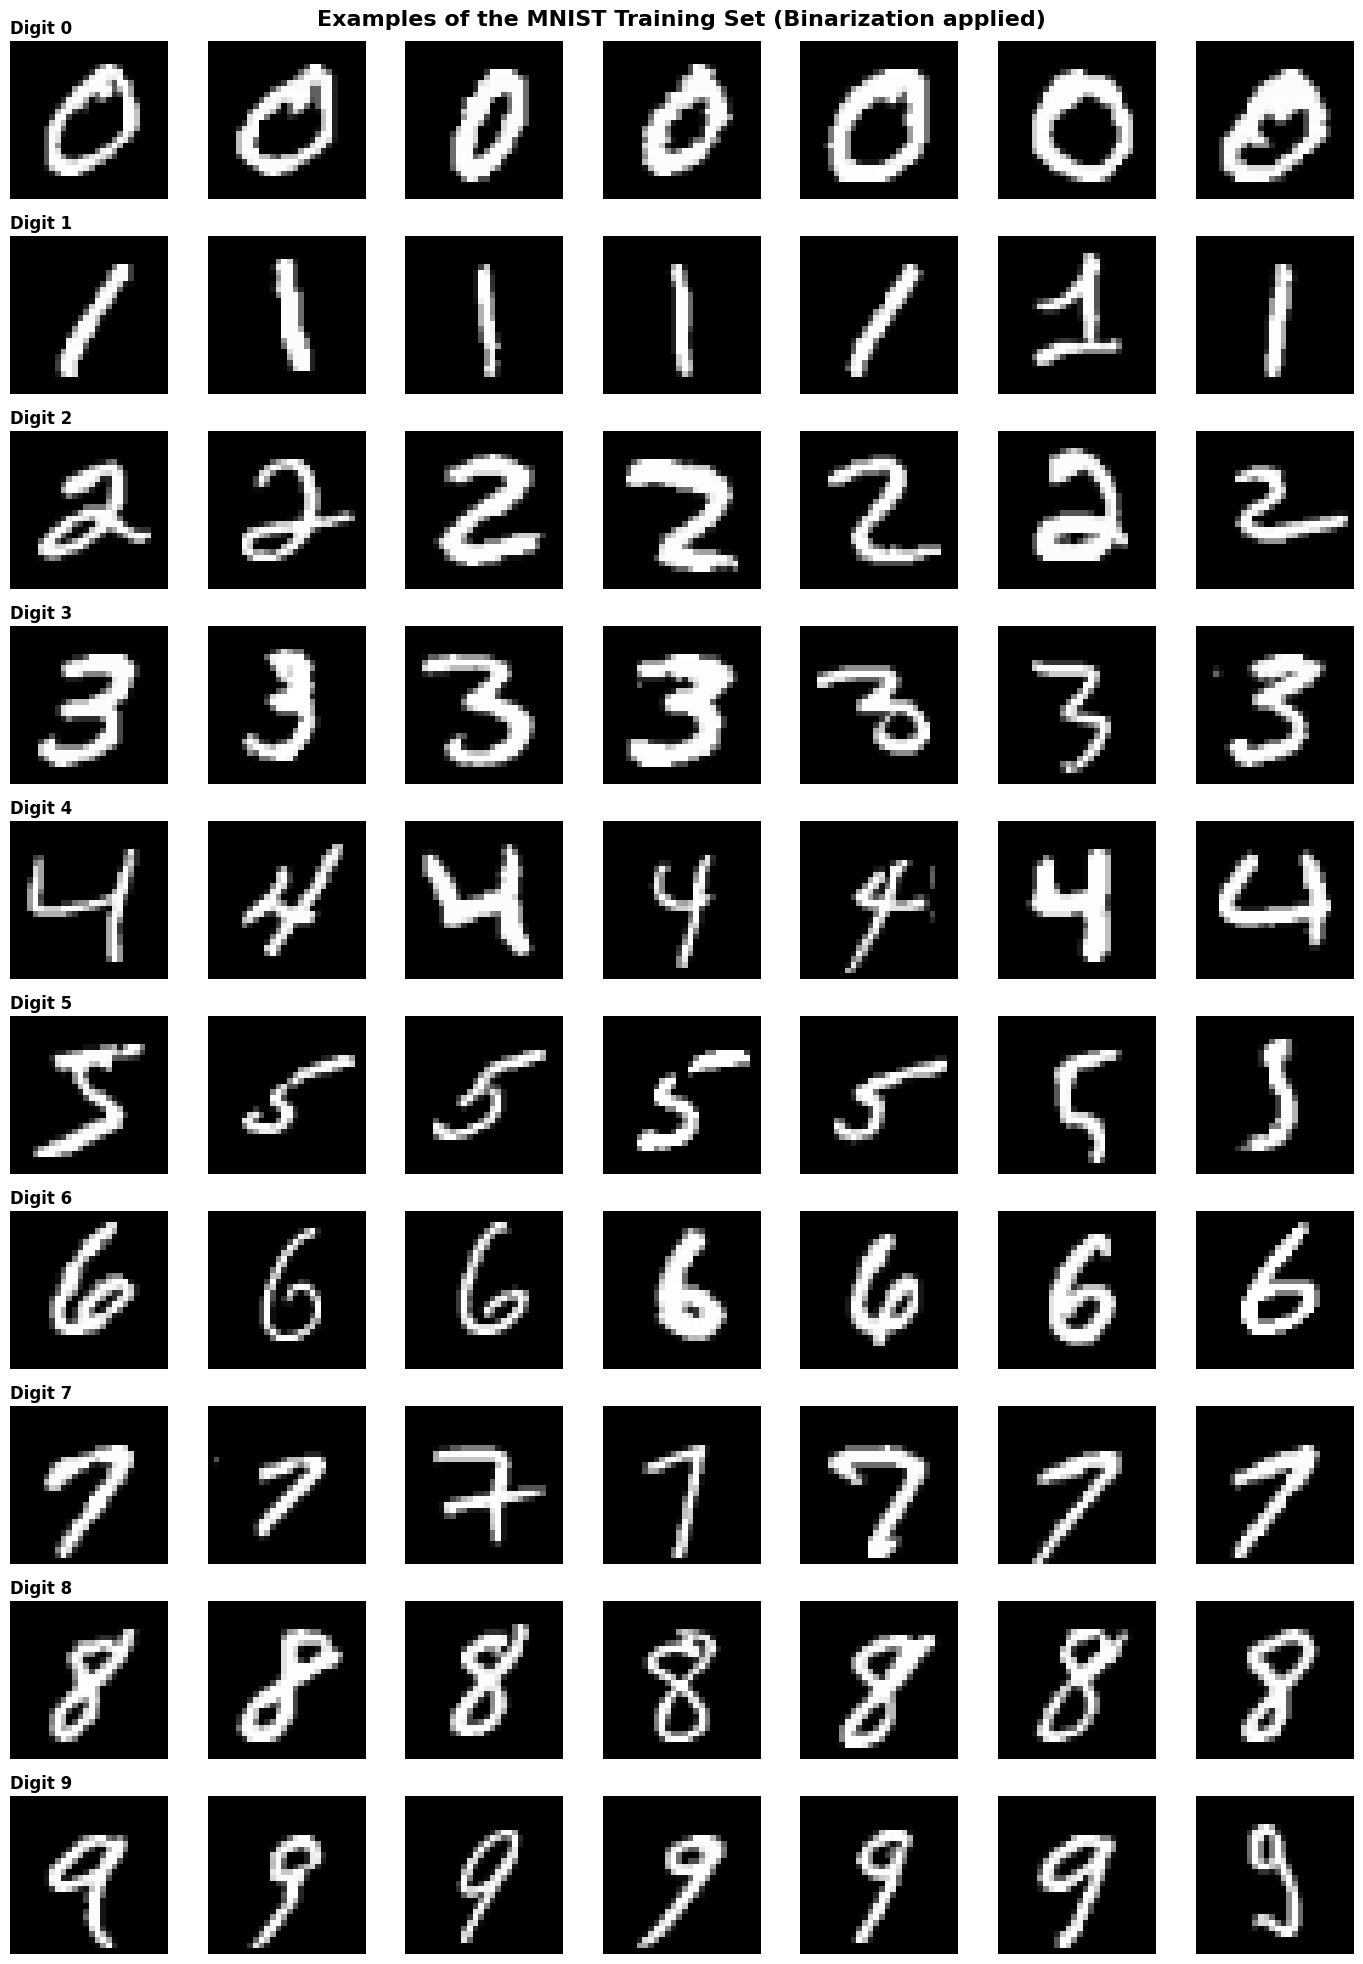

In [117]:
MAX_VAL = 255     # Each pixel value in the MNIST dataset is an integer between 0 and 255.
THRESHOLD = 128

# x_train = np.where(x_train_resized  > THRESHOLD, 1.0, 0.0).astype(np.float32)
# x_val   = np.where(x_val_resized    > THRESHOLD, 1.0, 0.0).astype(np.float32)

# Normalization to [0, 1] range
x_train = x_train_resized / MAX_VAL
x_val   = x_val_resized / MAX_VAL
show_examples(x_train, y_train, num_classes=10, num_photos=7, title="Examples of the MNIST Training Set (Binarization applied)")

### Creating DataLoaders

The DataLoaders are created for both the training and validation sets. The training DataLoader is set to shuffle the data, while the validation DataLoader is not shuffled.

In [118]:
BATCH_SIZE_TRAIN = 32
BATCH_SIZE_VAL = 100

# // TODO: Different

train_dataset   = TensorDataset(torch.from_numpy(x_train),  torch.from_numpy(y_train)   )
test_dataset    = TensorDataset(torch.from_numpy(x_val),    torch.from_numpy(y_val)     )

trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN,    shuffle=True    )
testloader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE_VAL,      shuffle=False   )

### Create the VAE

The model created in `vae.py` is used to create the Variational Autoencoder (VAE) model.
If possible, the model is moved to the GPU for faster training.

In [119]:
model = VAE().to(device)

### Defining loss, optimizer and LR scheduler

The loss function is defined (see its comments for details).

The optimizer is defined using the Adam optimizer.

A scheduler is defined to reduce the learning rate when the validation loss plateaus. The scheduler is set to monitor the validation loss and reduce the learning rate by a factor of 0.5 if the validation loss does not improve for 5 consecutive epochs. The minimum learning rate is set to 0.0001.

In [120]:
def vae_loss_function(x, mu_latent, log_var_latent, mu_reconstruction, std_reconstruction=0.5):
    """
    Calcula la función de pérdida del VAE según las fórmulas de la imagen.
    
    Parameters:
    - mu_reconstruction: La media de la distribución de reconstrucción (p_theta(x|z)). Dimensiones: (batch_size, input_dim)
    - x: El dato original de entrada aplanado. Dimensiones: (batch_size, input_dim)
    - mu_latent: La media calculada por el encoder (mu_theta(x)). Dimensiones: (batch_size, latent_dim)
    - log_var_latent: El logaritmo de la varianza del encoder. Dimensiones: (batch_size, latent_dim)
    - std_reconstruction: La desviación estándar de la distribución de reconstrucción. Por defecto 1.0.
    """
    # 1. Término de Reconstrucción: (1 / (2 * sigma^2)) * ||x - mu_phi(z)||^2
    # F.mse_loss con reduction='sum' calcula exactamente la norma al cuadrado ||x - y||^2 sumada sobre todo el batch.
    x_flattened = x.view(x.size(0), -1)  # Aplanamos x para que tenga las mismas dimensiones que mu_reconstruction

    recon_loss = F.mse_loss(mu_reconstruction, x_flattened, reduction='sum')
    recon_loss = recon_loss / (2.0 * std_reconstruction ** 2)

    # 2. Término KL Divergence (Solución analítica cerrada para Gaussianas)
    # D_KL( q(z|x) || p(z) ) donde p(z) ~ N(0, I)
    # Sumamos sobre las dimensiones latentes y sobre el batch.
    kl_loss = -0.5 * torch.sum(1 + log_var_latent - mu_latent.pow(2) - log_var_latent.exp())

    # La pérdida total que queremos MINIMIZAR
    total_loss = recon_loss + kl_loss
    
    return total_loss, recon_loss, kl_loss

In [121]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, threshold=0.001, min_lr=0.0001
)

### Training the model

In [122]:
history = {
    'train_recon_loss': [], 'train_kl_loss': [], 'weight_updates': [],
    'val_step_loss': [], 'val_step_updates': []
}

weight_update_count = 0
NUM_EPOCHS = 20

# 4. Bucle Principal de Entrenamiento
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()  # Activar modo entrenamiento
    running_epoch_loss = 0.0
    
    for batch_idx, (data, _) in enumerate(trainloader):
        data = data.to(device)  # Mover datos a GPU/CPU de forma dinámica
        batch_size = data.shape[0]
        
        # Resetear gradientes
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, log_var = model(data)
        
        # Calcular pérdida
        loss, recon_loss, kl_loss = vae_loss_function(data, mu, log_var, recon_batch)
        
        # Backward pass (Backpropagation)
        loss.backward()
        
        # Actualizar pesos
        optimizer.step()
        
        # Guardar métricas de este batch
        running_epoch_loss += loss.item()
        history['train_recon_loss'].append(recon_loss.item() / batch_size)
        history['train_kl_loss'].append(kl_loss.item() / batch_size)
        
        weight_update_count += 1
        history['weight_updates'].append(weight_update_count)

        # --- Validación Rápida cada 100 actualizaciones de pesos ---
        if weight_update_count % 100 == 0:
            model.eval()  # Modo evaluación (apaga el ruido del VAE)
            with torch.no_grad():  # Desactiva el cálculo de gradientes (ahorra memoria)
                # Tomar un lote del testloader
                val_data, _ = next(iter(testloader))
                val_data = val_data.to(device)
                
                v_recon, v_mu, v_log_var = model(val_data)
                v_loss, _, _ = vae_loss_function(val_data, v_mu, v_log_var, v_recon)
                
                # Guardar pérdida promedio de este lote de validación
                history['val_step_loss'].append(v_loss.item() / val_data.shape[0])
                history['val_step_updates'].append(weight_update_count)
            
            model.train()  # Regresar a modo entrenamiento

    # --- Fin de la Época: Evaluación Completa en el Set de Test ---
    model.eval()
    total_test_loss = 0.0
    
    with torch.no_grad():
        for test_data, _ in testloader:
            test_data = test_data.to(device)
            t_recon, t_mu, t_log_var = model(test_data)
            t_loss, _, _ = vae_loss_function(test_data, t_mu, t_log_var, t_recon)
            total_test_loss += t_loss.item()
            
    epoch_train_avg = running_epoch_loss / len(trainloader.dataset)
    epoch_test_avg = total_test_loss / len(testloader.dataset)
    
    # Actualizar el learning rate basado en la pérdida de entrenamiento
    scheduler.step(epoch_train_avg)
    
    print(f"====> Época: {epoch} | Pérdida Media Entren: {epoch_train_avg:.4f} | Pérdida Test: {epoch_test_avg:.4f}")

====> Época: 1 | Pérdida Media Entren: 76.8348 | Pérdida Test: 58.5917
====> Época: 2 | Pérdida Media Entren: 61.1606 | Pérdida Test: 55.4965
====> Época: 3 | Pérdida Media Entren: 58.4128 | Pérdida Test: 53.4537
====> Época: 4 | Pérdida Media Entren: 56.8403 | Pérdida Test: 54.7077
====> Época: 5 | Pérdida Media Entren: 55.7261 | Pérdida Test: 51.5268
====> Época: 6 | Pérdida Media Entren: 54.9346 | Pérdida Test: 51.4669
====> Época: 7 | Pérdida Media Entren: 54.3779 | Pérdida Test: 50.7983
====> Época: 8 | Pérdida Media Entren: 53.8675 | Pérdida Test: 51.1505
====> Época: 9 | Pérdida Media Entren: 53.5068 | Pérdida Test: 51.0516
====> Época: 10 | Pérdida Media Entren: 53.0542 | Pérdida Test: 49.7000
====> Época: 11 | Pérdida Media Entren: 52.8566 | Pérdida Test: 50.0147
====> Época: 12 | Pérdida Media Entren: 52.5194 | Pérdida Test: 49.6244
====> Época: 13 | Pérdida Media Entren: 52.4175 | Pérdida Test: 50.0726
====> Época: 14 | Pérdida Media Entren: 52.0935 | Pérdida Test: 48.9156
=

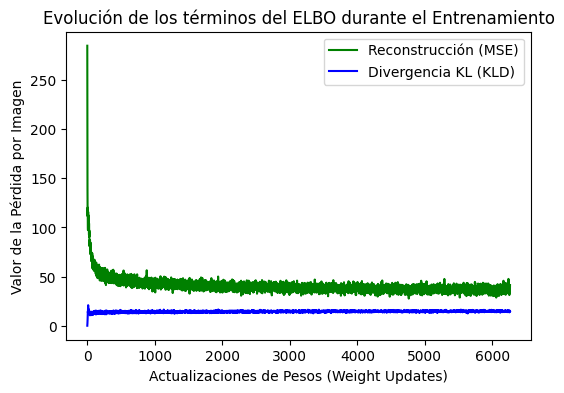


--- Visualizando Reconstrucciones en el set de Entrenamiento ---


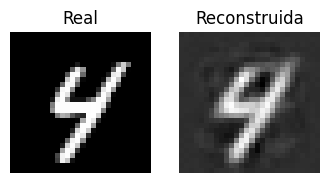

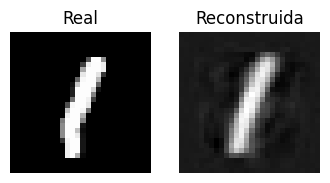

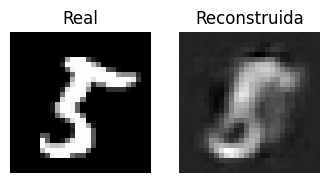

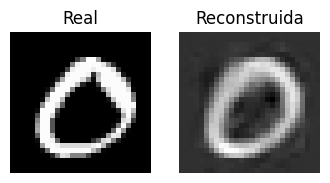

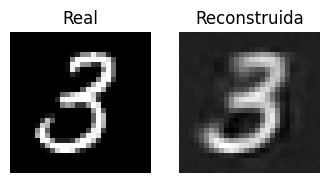

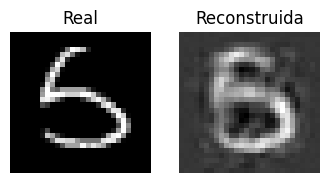

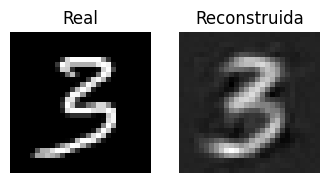

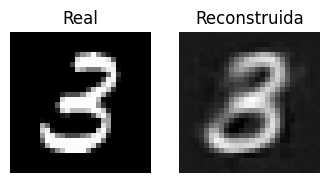


--- Visualizando Reconstrucciones en el set de Validación / Test ---


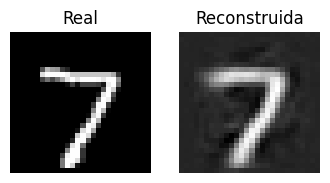

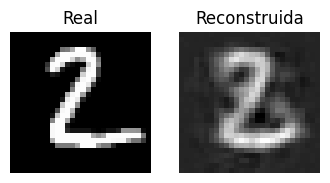

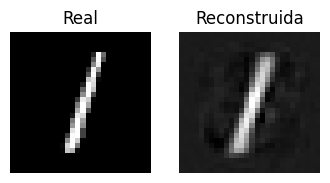

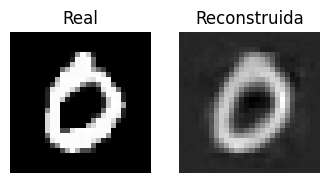

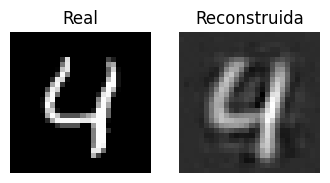

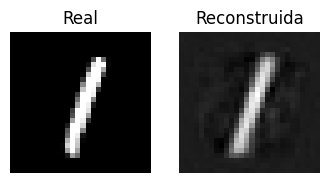

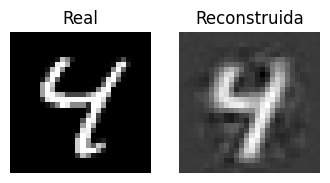

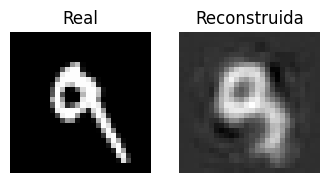


--- Generando nuevos dígitos imaginarios desde el espacio latente ---


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x8 and 10x512)

In [124]:

# Colocar el modelo en modo evaluación y asegurar el dispositivo correcto
model.eval()

# =====================================================================
# GRAFICA 1: Los dos componentes de la pérdida (BCE vs KLD)
# =====================================================================
plt.figure(figsize=(6, 4), dpi=100)
# Usamos el diccionario 'history' que armamos en el paso anterior
plt.plot(history['weight_updates'], history['train_recon_loss'], 'g', label='Reconstrucción (MSE)')
plt.plot(history['weight_updates'], history['train_kl_loss'], 'b', label='Divergencia KL (KLD)')
plt.title('Evolución de los términos del ELBO durante el Entrenamiento')
plt.xlabel('Actualizaciones de Pesos (Weight Updates)')
plt.ylabel('Valor de la Pérdida por Imagen')
plt.legend()
plt.show()

# =====================================================================
# GRAFICA 2 & 3: Reconstrucción de imágenes (Train y Test)
# =====================================================================
def visualizar_reconstrucciones(dataloader, titulo_set):
    print(f"\n--- Visualizando Reconstrucciones en el set de {titulo_set} ---")
    # Extraer un lote de datos
    imagenes, _ = next(iter(dataloader))
    imagenes = imagenes.to(device)
    
    with torch.no_grad():
        # Pasamos todo el batch por el modelo
        reconstruidas, _, _ = model(imagenes)
    
    # Dibujar las primeras 8 imágenes del lote
    for i in range(8):
        img_real = imagenes[i].cpu().numpy()
        # Cambiar el vector plano de 784 de vuelta a una matriz de 28x28 para pintar
        img_recon = reconstruidas[i].view(NEW_WIDTH, NEW_HEIGHT).cpu().numpy()
        
        fig, axarr = plt.subplots(1, 2, figsize=(4, 2))
        axarr[0].imshow(img_real, cmap='gray')
        axarr[0].set_title("Real")
        axarr[0].axis('off')
        
        axarr[1].imshow(img_recon, cmap='gray')
        axarr[1].set_title("Reconstruida")
        axarr[1].axis('off')
        plt.show()

# Ejecutar las visualizaciones
visualizar_reconstrucciones(trainloader, "Entrenamiento")
visualizar_reconstrucciones(testloader, "Validación / Test")

# =====================================================================
# GRAFICA 4: Generación de contenido NUEVO desde el espacio latente
# =====================================================================
print("\n--- Generando nuevos dígitos imaginarios desde el espacio latente ---")
with torch.no_grad():
    for i in range(8):
        # Muestreamos directamente de una distribución normal estándar N(0, 1) en la GPU/CPU
        # Creamos un único vector aleatorio de tamaño 8 (nuestro tamaño latente)
        vector_latente_aleatorio = torch.randn(1, 8).to(device)
        
        # Le pedimos SOLAMENTE al decoder que nos dibuje una imagen a partir de este vector
        imagen_inventada = model.decode(vector_latente_aleatorio)
        imagen_cuadrada = imagen_inventada.view(14, 14).cpu().numpy()
        
        plt.figure(figsize=(2, 2))
        plt.imshow(imagen_cuadrada, cmap='gray')
        plt.title(f"Generada #{i+1}")
        plt.axis('off')
        plt.show()

# =====================================================================
# GRAFICA 5: Comparativa de Reconstrucción (Train vs Validation)
# =====================================================================
plt.figure(figsize=(6, 4), dpi=100)
plt.plot(history['weight_updates'], history['train_bce'], 'g', label='BCE Entrenamiento')
plt.plot(history['val_step_updates'], history['val_step_loss'], 'r', label='BCE Validación')
plt.title('Error de Reconstrucción: Entrenamiento vs Validación')
plt.xlabel('Actualizaciones de Pesos (Weight Updates)')
plt.ylabel('Valor de la Pérdida')
plt.legend()
plt.show()